In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str


In [5]:
def generate_joke(state: JokeState):

    prompt = f"Generate a joke on the following topic \n{state['topic']}"
    response = llm.invoke(prompt).content
    return {'joke': response}

In [8]:
def explain_joke(state: JokeState):

    joke=state['joke']
    prompt = f"Write an explanation for the joke - {joke} in under 50 words"

    response = llm.invoke(prompt).content

    return {'explanation': response}

In [9]:
graph = StateGraph(JokeState)



graph.add_node('generate_joke',generate_joke)
graph.add_node('explain_joke',explain_joke)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke','explain_joke')
graph.add_edge('explain_joke',END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)


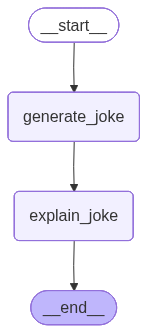

In [10]:
workflow

In [42]:
initial_state={'topic':'pizza'}

config3 = {"configurable":{"thread_id":"3"}}

workflow.invoke(initial_state, config=config3)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!',
 'explanation': 'The joke relies on a play on words, "crusty" referring to the pizza\'s crust, but also meaning irritable or grumpy, creating a humorous pun.'}

In [30]:
workflow.get_state(config3)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explanation': 'The joke plays on "crusty" having a double meaning, referring to the pizza\'s crust and being irritable, creating a humorous pun.'}, next=(), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173cd4-39d0-60f5-8002-6dc2e5d6a2be'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-29T15:14:46.504882+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173cd4-3653-643f-8001-85e4db2ee5ee'}}, tasks=(), interrupts=())

In [43]:
list(workflow.get_state_history(config3))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!', 'explanation': 'The joke relies on a play on words, "crusty" referring to the pizza\'s crust, but also meaning irritable or grumpy, creating a humorous pun.'}, next=(), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173d19-1f06-62aa-8006-5ed9c90fe61a'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-06-29T15:45:35.900535+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173d19-1bbc-6c8d-8005-876d15cb807e'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!', 'explanation': 'The joke plays on "crusty" having a double meaning, referring to the pizza\'s crust and being irritable, creating a humorous pun.'}, next=('explain_joke',), config={'configurable

In [44]:

list(workflow.get_state_history(config3))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!', 'explanation': 'The joke relies on a play on words, "crusty" referring to the pizza\'s crust, but also meaning irritable or grumpy, creating a humorous pun.'}, next=(), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173d19-1f06-62aa-8006-5ed9c90fe61a'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-06-29T15:45:35.900535+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173d19-1bbc-6c8d-8005-876d15cb807e'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!', 'explanation': 'The joke plays on "crusty" having a double meaning, referring to the pizza\'s crust and being irritable, creating a humorous pun.'}, next=('explain_joke',), config={'configurable

Time Travel

In [33]:
workflow.get_state({"configurable":{"thread_id":"2","checkpoint_id":"1f173cc9-f1c3-6762-8000-3e8bf5a39027"}})

StateSnapshot(values={'topic': 'oreo'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f173cc9-f1c3-6762-8000-3e8bf5a39027'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-29T15:10:10.514518+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f173cc9-f1c3-6761-bfff-cb6ea53e03d5'}}, tasks=(PregelTask(id='411da777-b833-3d39-231f-dbb68e71b814', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the Oreo go to therapy?\n\nBecause it was feeling crumby about being split in the middle!'}),), interrupts=())

In [ ]:
workflow.invoke(None,{"configurable":{"thread_id":"2","checkpoint_id":"1f173cc9-f1c3-6762-8000-3e8bf5a39027"}})

{'topic': 'oreo',
 'joke': 'Why did the Oreo go to therapy?\n\nBecause it was feeling crumby and needed to work through some twist-ed issues.',
 'explanation': 'The joke plays on Oreo\'s crumbly nature and twisting apart, using "crumby" and "twist-ed" to describe emotional struggles, creating a humorous pun.'}

Updating State

In [47]:
workflow.update_state({"configurable":{"thread_id":"3","checkpoint_ns":"","checkpoint_id":"1f173cd4-316d-6696-bfff-38d1d24c8adc"}},{"topic": "samosa"})

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f173d24-9733-658f-8000-384b3ac641e6'}}

In [49]:
list(workflow.get_state_history(config3))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173d24-9733-658f-8000-384b3ac641e6'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-06-29T15:50:43.780955+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173cd4-316d-6696-bfff-38d1d24c8adc'}}, tasks=(PregelTask(id='a18bc8cc-ffbb-4106-a179-0252c4d7f6d1', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty!', 'explanation': 'The joke relies on a play on words, "crusty" referring to the pizza\'s crust, but also meaning irritable or grumpy, creating a humorous pun.'}, next=(), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1

In [50]:
workflow.invoke(None,{'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173d24-9733-658f-8000-384b3ac641e6'}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside!',
 'explanation': "The joke plays on a samosa's crunchy exterior and empty interior, metaphorically describing emotional unfulfillment, making it a humorous reason for therapy."}

In [52]:
list(workflow.get_state_history(config3))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside!', 'explanation': "The joke plays on a samosa's crunchy exterior and empty interior, metaphorically describing emotional unfulfillment, making it a humorous reason for therapy."}, next=(), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173d2b-327f-61d4-8002-3912b144c4af'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-29T15:53:41.126190+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f173d2b-2e9c-6ec9-8001-5200af375377'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling a little "crunchy" on the outside and "empty" on the inside!'}, next=('explain_joke',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': 